In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/akashkumarsamantray/food-delivery-germany/food-delivery-market-analysis-germany/data/cleaned_reviews.csv')
df.head()

,reviewId,userName,content,score,thumbsUpCount,at,replyContent,repliedAt,appVersion,app_name,review_year,review_month,review_day,review_hour,sentiment,review_length,word_count,has_reply
0,06626e61-d64f-4e6c-933e-d581256aac7b,Sara Levermann,Ich finde diese App sehr gut.🙂...,5,0,2026-06-09 21:59:48,No Reply,NaN,26.23.3,Wolt,2026,6,Tuesday,21,Positive,33,6,0
1,97aad388-9203-45eb-8499-db5de7b7e666,Matthias Ri,If anything goes wrong with an order don't exp...,1,0,2026-06-09 06:17:59,No Reply,NaN,26.22.3,Wolt,2026,6,Tuesday,6,Negative,107,17,0
2,b96870a4-171e-48cc-bf40-3e4140b649cc,Jean Wolff,Menü für 2 Personnen bestellt und gezahlt. Ein...,1,1,2026-06-08 11:58:17,No Reply,NaN,26.22.3,Wolt,2026,6,Monday,11,Negative,409,60,0
3,ec2966b1-2f78-4920-b4be-fb613c8b0689,Latifa Khennoussi,tolle App,5,0,2026-06-07 23:16:23,No Reply,NaN,26.22.3,Wolt,2026,6,Sunday,23,Positive,9,2,0
4,97cf249e-188c-4c95-88f6-0eef32b63e24,Wahid Alisaleha,Super,5,0,2026-06-07 21:40:12,No Reply,NaN,26.22.3,Wolt,2026,6,Sunday,21,Positive,5,1,0


In [3]:
## Target variables

# Kept only Positive and Negative (dropped Neutral — it was too ambiguous for binary classification)
df_ml = df[df['sentiment'] != 'Neutral'].copy()

# Encode target: Positive = 1, Negative = 0
df_ml['label'] = (df_ml['sentiment'] == 'Positive').astype(int)

print(df_ml['label'].value_counts())
print(f"Total samples: {len(df_ml)}")

label
0    3367
1    2426
Name: count, dtype: int64
Total samples: 5793


In [4]:
## Prepared features using TF-IDF on review text

tfidf = TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1,2))
X = tfidf.fit_transform(df_ml['content'])
y = df_ml['label']

In [5]:
## Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 4634
Test size: 1159


In [6]:
## Trained Logistic Regression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [7]:
## Evaluated model

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95       674
    Positive       0.93      0.91      0.92       485

    accuracy                           0.94      1159
   macro avg       0.94      0.93      0.93      1159
weighted avg       0.94      0.94      0.94      1159



In [ ]:
## Insights

## Negative reviews: 95% correctly identified 

## Positive reviews: 91% correctly identified

## Overall accuracy 94% — very strong for a text classification model

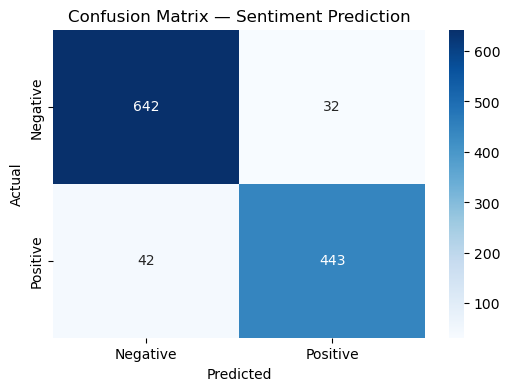

In [8]:
## Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Sentiment Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

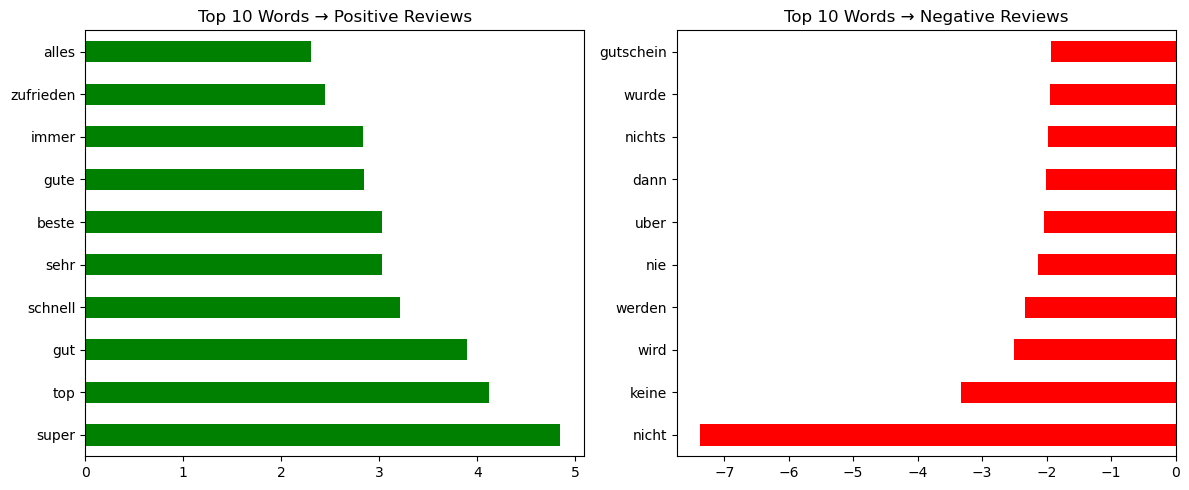

In [9]:
## Top words driving Positive vs Negative predictions

feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

top_positive = pd.Series(coefs, index=feature_names).nlargest(10)
top_negative = pd.Series(coefs, index=feature_names).nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top_positive.plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top 10 Words → Positive Reviews')

top_negative.plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top 10 Words → Negative Reviews')

plt.tight_layout()
plt.show()

In [10]:
## Saved model for Streamlit 

import joblib
joblib.dump(model, 'data/sentiment_model.pkl')
joblib.dump(tfidf, 'data/tfidf_vectorizer.pkl')
print("Model and vectorizer saved!")

Model and vectorizer saved!
